In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import seaborn as sns
from pathlib import Path

In [3]:
original_tsv_path = Path('/Users/thomasbush/Downloads/raw_data/amino_acid_genotypes_to_brightness.tsv')
results_directory = Path('/Users/thomasbush/Downloads/results_protein_rsa')

mutation_df = pd.read_csv(original_tsv_path, sep='\t')
high_effect_dir = results_directory / 'high_effect'
neutral_dir = results_directory / 'neutral'

In [ ]:
# check structural scores:
structure_scores_neutral = pd.read_csv(neutral_dir / 'structure_scores.csv')
structure_scores_high_effect = pd.read_csv(high_effect_dir / 'structure_scores.csv')

Now we can compute a plot showing the distribution of TM-score and teh mutation effect from the two dataset:
- use idx from the structure scores to obtain teh mutation effect in mutation_df["medianBrightness"]

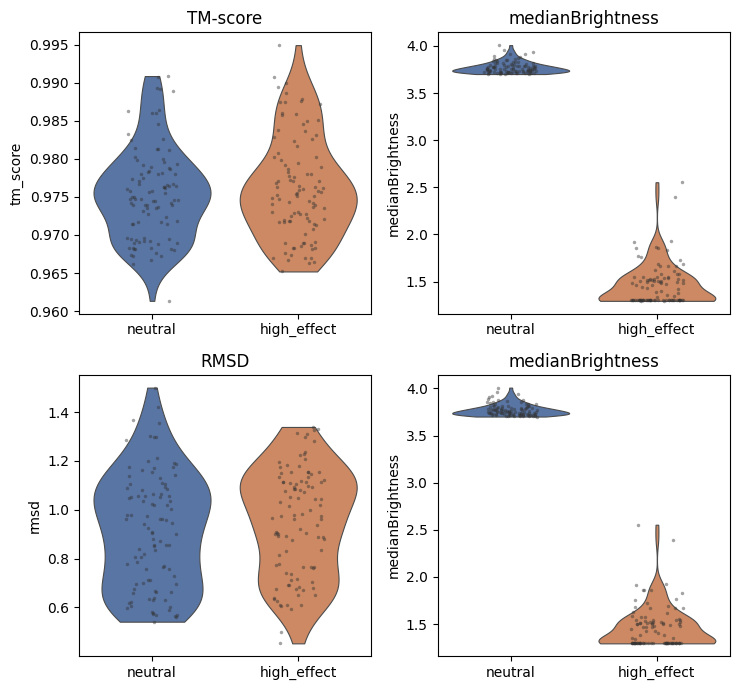

In [15]:
# sequence_idx in structure_scores = 0-based row index in the Sarkisyan TSV (same as seq_XXXXX)
_idx = "sequence_idx" if "sequence_idx" in structure_scores_neutral.columns else "idx"

def attach_brightness(scores: pd.DataFrame, label: str) -> pd.DataFrame:
    out = scores.copy()
    out["cohort"] = label
    out["medianBrightness"] = out[_idx].map(
        lambda i: mutation_df["medianBrightness"].iloc[int(i)]
        if 0 <= int(i) < len(mutation_df)
        else np.nan
    )
    return out

plot_df = pd.concat(
    [
        attach_brightness(structure_scores_neutral, "neutral"),
        attach_brightness(structure_scores_high_effect, "high_effect"),
    ],
    ignore_index=True,
)

# Violin (density) + strip (raw points) per cohort — row 1: TM + brightness; row 2: RMSD + brightness
order = ["neutral", "high_effect"]
colors = ["#4c72b0", "#dd8452"]
panels = [
    [("tm_score", "TM-score"), ("medianBrightness", "medianBrightness")],
    [("rmsd", "RMSD"), ("medianBrightness", "medianBrightness")],
]
fig, axes = plt.subplots(2, 2, figsize=(7.5, 7), sharey=False)
for i, row in enumerate(panels):
    for j, (col, title) in enumerate(row):
        ax = axes[i, j]
        sns.violinplot(
            data=plot_df,
            x="cohort",
            y=col,
            hue="cohort",
            order=order,
            hue_order=order,
            dodge=False,
            ax=ax,
            inner=None,
            cut=0,
            palette=colors,
            linewidth=0.8,
            legend=False,
        )
        sns.stripplot(
            data=plot_df,
            x="cohort",
            y=col,
            order=order,
            ax=ax,
            color="0.2",
            alpha=0.45,
            size=2.5,
            jitter=0.18,
            dodge=False,
        )
        ax.set_title(title)
        ax.set_xlabel("")
fig.tight_layout()
plt.show()

Now that we have seen that the differences between the classes are not present (similar to the study), we can compute differences between their hidden representations

TODO: add effective strain to the outputs

In [16]:
high_effect_divergence = pd.read_csv(high_effect_dir / 'high_effect_divergence.csv')
neutral_divergence = pd.read_csv(neutral_dir / 'neutral_divergence.csv')

In [19]:
high_effect_divergence

,mutant_id,class,step,layer,cosine_div,frobenius_div
0,seq_00132,high_effect,0,0,0.000406,0.030463
1,seq_00132,high_effect,0,1,0.000274,0.025577
2,seq_00132,high_effect,0,2,0.000228,0.023993
3,seq_00132,high_effect,0,3,0.000223,0.022778
4,seq_00132,high_effect,0,4,0.000217,0.022056
...,...,...,...,...,...,...
70395,seq_53714,high_effect,10,59,0.001536,0.062058
70396,seq_53714,high_effect,10,60,0.001563,0.062704
70397,seq_53714,high_effect,10,61,0.001832,0.067289
70398,seq_53714,high_effect,10,62,0.002589,0.079359


In [ ]:
divergence_df = pd.concat([high_effect_divergence, neutral_divergence], ignore_index=True)

# Use last recycling step for cleaner plots
last_step = divergence_df["step"].max()
div_last = divergence_df[divergence_df["step"] == last_step].copy()
print(f"Using step {last_step}, {div_last['mutant_id'].nunique()} mutants, {div_last.shape[0]} rows")

### Divergence across spatial scales

Compare how high-effect vs neutral mutations diverge from WT at different spatial resolutions:
- **Mutation site** (`mut_site_div`): only the mutated residue(s)
- **Window ±5 / ±10**: local neighborhood around the mutation
- **Max** (`max_div`): most perturbed residue anywhere (allosteric signal)
- **Mean** (`mean_div`) / **cosine_div**: full-sequence average (global perturbation baseline)

In [ ]:
# Multi-panel: divergence vs layer for each spatial scale
# Works with both old format (cosine_div) and new format (mut_site_div, window_*, etc.)
candidate_metrics = {
    "mut_site_div": "Mutation site only",
    "window_5_div": "Window ±5 residues",
    "window_10_div": "Window ±10 residues",
    "max_div": "Max residue",
    "mean_div": "Full sequence mean",
    "cosine_div": "Cosine divergence (full seq)",
    "frobenius_div": "Frobenius divergence (full seq)",
}
metrics = {k: v for k, v in candidate_metrics.items() if k in div_last.columns}

n = len(metrics)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=False)
if n == 1:
    axes = [axes]

palette = {"high_effect": "#dd8452", "neutral": "#4c72b0"}

for ax, (col, title) in zip(axes, metrics.items()):
    sns.lineplot(
        data=div_last,
        x="layer",
        y=col,
        hue="class",
        hue_order=["neutral", "high_effect"],
        palette=palette,
        errorbar="se",
        estimator="mean",
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Divergence")
    ax.get_legend().remove()

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.0, 1.0))
fig.tight_layout()
plt.show()

In [ ]:
# Overlay all spatial scales on one plot per cohort
# Pick whichever columns exist in the data
scale_cols = [c for c in ["mut_site_div", "window_5_div", "window_10_div", "max_div", "mean_div", "cosine_div"] if c in div_last.columns]
scale_labels = {
    "mut_site_div": "Mut site",
    "window_5_div": "Window ±5",
    "window_10_div": "Window ±10",
    "max_div": "Max residue",
    "mean_div": "Full seq mean",
    "cosine_div": "Full seq cosine",
}

long = div_last.melt(
    id_vars=["mutant_id", "class", "step", "layer"],
    value_vars=scale_cols,
    var_name="scale",
    value_name="divergence",
)
long["scale"] = long["scale"].map(scale_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, cohort in zip(axes, ["high_effect", "neutral"]):
    sub = long[long["class"] == cohort]
    sns.lineplot(
        data=sub,
        x="layer",
        y="divergence",
        hue="scale",
        hue_order=[scale_labels[c] for c in scale_cols],
        errorbar="se",
        estimator="mean",
        ax=ax,
    )
    ax.set_title(cohort.replace("_", " ").title())
    ax.set_xlabel("Layer")
    ax.set_ylabel("Divergence (mean ± SEM)")

axes[0].get_legend().remove()
axes[1].legend(title="Scale", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

In [ ]:
# Divergence evolution across recycling steps
# Shows how the model refines its representation of the mutation over recycling
metric_col = next(
    (c for c in ["mut_site_div", "cosine_div", "mean_div"] if c in divergence_df.columns),
    divergence_df.columns[-1],
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, cohort in zip(axes, ["high_effect", "neutral"]):
    sub = divergence_df[divergence_df["class"] == cohort]
    sns.lineplot(
        data=sub,
        x="layer",
        y=metric_col,
        hue="step",
        palette="viridis",
        errorbar="se",
        estimator="mean",
        ax=ax,
        legend="full",
    )
    ax.set_title(cohort.replace("_", " ").title())
    ax.set_xlabel("Layer")
    ax.set_ylabel(f"{metric_col} (mean ± SEM)")

axes[0].get_legend().remove()
axes[1].legend(title="Recycling step", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Divergence across recycling steps", y=1.02)
fig.tight_layout()
plt.show()

### Divergence vs structural quality

Key question: does representational divergence predict structural quality (TM-score) better than just knowing the mutation class? If so, the internal representations carry information about the functional impact of mutations that goes beyond what structure alone reveals.

In [ ]:
# Build per-mutant summary: aggregate divergence across layers
# Use cosine_div (available now), will switch to mut_site_div when new results arrive
div_col = next(c for c in ["mut_site_div", "cosine_div"] if c in divergence_df.columns)

# Summarise at last step: mean and max divergence across layers per mutant
last = divergence_df[divergence_df["step"] == divergence_df["step"].max()]
mutant_summary = (
    last.groupby(["mutant_id", "class"])
    .agg(
        div_mean=(div_col, "mean"),      # average divergence across all layers
        div_max=(div_col, "max"),         # peak divergence (worst layer)
        div_last_layer=(div_col, "last"), # divergence at final layer
    )
    .reset_index()
)

# Extract numeric seq index for merging with structure scores
mutant_summary["sequence_idx"] = mutant_summary["mutant_id"].str.extract(r"seq_(\d+)").astype(int)

# Merge with structure scores
scores_all = pd.concat([
    structure_scores_high_effect.assign(cohort="high_effect"),
    structure_scores_neutral.assign(cohort="neutral"),
], ignore_index=True)

merged = mutant_summary.merge(scores_all, on="sequence_idx", how="inner")

# Attach brightness from Sarkisyan TSV
merged["brightness"] = merged["sequence_idx"].map(
    lambda i: mutation_df["medianBrightness"].iloc[i]
    if 0 <= i < len(mutation_df) else np.nan
)

print(f"Merged {len(merged)} mutants with both divergence and structure scores")
merged.head()

In [ ]:
# Scatter: divergence vs TM-score and divergence vs brightness
palette = {"high_effect": "#dd8452", "neutral": "#4c72b0"}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
div_metrics = ["div_mean", "div_max", "div_last_layer"]
div_labels = ["Mean div (all layers)", "Max div (peak layer)", "Div at last layer"]

for j, (dm, dl) in enumerate(zip(div_metrics, div_labels)):
    # Row 0: div vs TM-score
    ax = axes[0, j]
    for cohort in ["neutral", "high_effect"]:
        sub = merged[merged["class"] == cohort]
        ax.scatter(sub[dm], sub["tm_score"], alpha=0.6, s=30,
                   label=cohort, color=palette[cohort], edgecolors="white", linewidth=0.3)
    r = merged[[dm, "tm_score"]].corr().iloc[0, 1]
    ax.set_xlabel(dl)
    ax.set_ylabel("TM-score")
    ax.set_title(f"vs TM-score (r={r:.3f})")
    if j == 0:
        ax.legend()

    # Row 1: div vs brightness
    ax = axes[1, j]
    for cohort in ["neutral", "high_effect"]:
        sub = merged[merged["class"] == cohort]
        ax.scatter(sub[dm], sub["brightness"], alpha=0.6, s=30,
                   label=cohort, color=palette[cohort], edgecolors="white", linewidth=0.3)
    r = merged[[dm, "brightness"]].corr().iloc[0, 1]
    ax.set_xlabel(dl)
    ax.set_ylabel("Median brightness")
    ax.set_title(f"vs Brightness (r={r:.3f})")

fig.suptitle("Representational divergence vs structural / functional outcomes", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

In [ ]:
# Per-layer correlation: at which layers does divergence best predict TM-score / brightness?
from scipy.stats import spearmanr

last = divergence_df[divergence_df["step"] == divergence_df["step"].max()].copy()
last["sequence_idx"] = last["mutant_id"].str.extract(r"seq_(\d+)").astype(int)
last = last.merge(scores_all[["sequence_idx", "tm_score", "cohort"]], on="sequence_idx", how="inner")
last["brightness"] = last["sequence_idx"].map(
    lambda i: mutation_df["medianBrightness"].iloc[i] if 0 <= i < len(mutation_df) else np.nan
)

layers = sorted(last["layer"].unique())
corr_tm = []
corr_br = []
for layer in layers:
    sub = last[last["layer"] == layer]
    r_tm, _ = spearmanr(sub[div_col], sub["tm_score"])
    r_br, _ = spearmanr(sub[div_col], sub["brightness"])
    corr_tm.append(r_tm)
    corr_br.append(r_br)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(layers, corr_tm, "o-", markersize=4, label="vs TM-score")
ax.plot(layers, corr_br, "s-", markersize=4, label="vs Brightness")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
ax.set_xlabel("Layer")
ax.set_ylabel("Spearman r")
ax.set_title("Per-layer correlation: divergence vs outcome")
ax.legend()
fig.tight_layout()
plt.show()

In [ ]:
# Heatmap: per-layer divergence evolution across recycling steps (averaged over mutants)
# Separate heatmaps for each cohort
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, cohort in zip(axes, ["high_effect", "neutral"]):
    sub = divergence_df[divergence_df["class"] == cohort]
    pivot = sub.pivot_table(index="step", columns="layer", values=div_col, aggfunc="mean")
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="magma",
        xticklabels=8,
        yticklabels=1,
        cbar_kws={"label": f"Mean {div_col}"},
    )
    ax.set_title(f"{cohort.replace('_', ' ').title()}")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Recycling step")

fig.suptitle("Divergence heatmap: recycling step x layer", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

In [ ]:
# Per-step correlation with TM-score: does predictive power improve with recycling?
steps = sorted(divergence_df["step"].unique())
step_corr_tm = []
step_corr_br = []

for step in steps:
    sub = divergence_df[divergence_df["step"] == step].copy()
    # Aggregate over layers per mutant
    agg = sub.groupby(["mutant_id", "class"])[div_col].mean().reset_index()
    agg["sequence_idx"] = agg["mutant_id"].str.extract(r"seq_(\d+)").astype(int)
    agg = agg.merge(scores_all[["sequence_idx", "tm_score"]], on="sequence_idx", how="inner")
    agg["brightness"] = agg["sequence_idx"].map(
        lambda i: mutation_df["medianBrightness"].iloc[i] if 0 <= i < len(mutation_df) else np.nan
    )
    r_tm, _ = spearmanr(agg[div_col], agg["tm_score"])
    r_br, _ = spearmanr(agg[div_col], agg["brightness"].dropna()) if agg["brightness"].notna().sum() > 5 else (np.nan, np.nan)
    step_corr_tm.append(r_tm)
    step_corr_br.append(r_br)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(steps, step_corr_tm, "o-", markersize=6, label="vs TM-score")
ax.plot(steps, step_corr_br, "s-", markersize=6, label="vs Brightness")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
ax.set_xlabel("Recycling step")
ax.set_ylabel("Spearman r (div vs outcome)")
ax.set_title("Does divergence become more predictive with recycling?")
ax.legend()
ax.set_xticks(steps)
fig.tight_layout()
plt.show()

In [ ]:
# Individual mutant trajectories: top-5 most divergent vs bottom-5
# Shows whether high-divergence mutants are consistently different across layers
last_agg = (
    div_last.groupby(["mutant_id", "class"])[div_col]
    .mean()
    .reset_index()
    .sort_values(div_col, ascending=False)
)
top5 = last_agg.head(5)["mutant_id"].tolist()
bot5 = last_agg.tail(5)["mutant_id"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (ids, title) in zip(axes, [(top5, "Top 5 most divergent"), (bot5, "Bottom 5 least divergent")]):
    sub = div_last[div_last["mutant_id"].isin(ids)]
    sns.lineplot(
        data=sub,
        x="layer",
        y=div_col,
        hue="mutant_id",
        style="class",
        ax=ax,
        legend="full",
    )
    ax.set_title(title)
    ax.set_xlabel("Layer")
    ax.set_ylabel(f"{div_col}")
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
plt.show()

In [ ]:
# Separation power: AUROC of divergence for classifying high_effect vs neutral at each layer
from sklearn.metrics import roc_auc_score

aurocs = []
for layer in sorted(div_last["layer"].unique()):
    sub = div_last[div_last["layer"] == layer]
    labels = (sub["class"] == "high_effect").astype(int)
    try:
        auc = roc_auc_score(labels, sub[div_col])
    except ValueError:
        auc = np.nan
    aurocs.append(auc)

layers = sorted(div_last["layer"].unique())

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(layers, aurocs, "o-", markersize=4, color="#2ca02c")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.5, label="chance")
ax.set_xlabel("Layer")
ax.set_ylabel("AUROC")
ax.set_title("Can divergence separate high-effect from neutral at each layer?")
ax.legend()
ax.set_ylim(0.3, 1.0)
fig.tight_layout()
plt.show()

print(f"Best AUROC: {max(aurocs):.3f} at layer {layers[np.argmax(aurocs)]}")
print(f"Last layer AUROC: {aurocs[-1]:.3f}")